In [2]:
from google.colab import drive
import os

# 1. Ngắt kết nối Drive hiện tại (nếu có)
drive.flush_and_unmount()

# 2. Xóa sạch thư mục mount cũ để đảm bảo không bị lỗi "Already contains files"
!rm -rf /content/drive

# 3. Kết nối lại
drive.mount('/content/drive')

# 4. Kiểm tra lại đường dẫn
os.chdir('/content/drive/MyDrive/PROJECT')
print("Đã kết nối lại thành công tới:", os.getcwd())

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Đã kết nối lại thành công tới: /content/drive/MyDrive/PROJECT


# Notebook 6: Final Comparison and Statistical Analysis

Notebook này tổng hợp toàn bộ kết quả từ các notebook trước để so sánh, phân tích và kết luận cuối cùng cho bài toán gom cụm văn bản báo chí tiếng Việt.

Các nguồn kết quả được sử dụng:

- Notebook 3: lexical baseline và FP-Max enrichment trên nhánh lexical.
- Notebook 4: MiniLM semantic baseline.
- Notebook 5: MiniLM + FP-Max controlled hybrid.

Notebook 6 không tạo đặc trưng mới, không encode lại MiniLM, không khai thác lại FP-Max và không chạy lại các mô hình nặng. Thay vào đó, notebook chỉ load các output đã lưu để tổng hợp, so sánh và phân tích.

Các mục tiêu chính của Notebook 6:

- Tạo bảng so sánh cuối cùng giữa các mô hình chính.
- Trực quan hóa kết quả so sánh.
- Phân tích mức cải thiện giữa các nhóm mô hình.
- Thực hiện hoặc thảo luận kiểm định thống kê khi dữ liệu phù hợp.
- Phân tích lỗi thông qua bảng chéo cụm - chuyên mục và các bài bị gom lệch cụm.
- Tổng hợp khả năng diễn giải của FP-Max thông qua pattern đồng xuất hiện.
- Trả lời các câu hỏi nghiên cứu RQ1, RQ2 và RQ3.
- Đưa ra kết luận cuối cùng cho toàn bộ thực nghiệm.

Lưu ý phương pháp:

- Không rời rạc hóa MiniLM embedding.
- Không chạy FP-Max trực tiếp trên MiniLM embedding.
- FP-Max chỉ được khai thác từ transaction nhị phân của `lexical_text` ở Notebook 3.
- Trong Notebook 5, FP-Max chỉ được dùng như tín hiệu lexical bổ sung có kiểm soát cho MiniLM thông qua hệ số `alpha` nhỏ.

Ba câu hỏi nghiên cứu chính:

**RQ1:** MiniLM có cải thiện chất lượng gom cụm văn bản báo chí tiếng Việt so với các phương pháp lexical baseline như TF-IDF/BM25 không?

**RQ2:** FP-Max enrichment có cải thiện hoặc thay đổi chất lượng gom cụm của TF-IDF baseline không?

**RQ3:** FP-Max pattern features có thể bổ sung khả năng diễn giải và/hoặc cải thiện chất lượng gom cụm khi ghép có kiểm soát với MiniLM không?

In [3]:
# Cell 2: Import thư viện và khai báo đường dẫn

import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, ttest_rel
from sklearn.metrics import confusion_matrix

# Tắt warning phụ để output gọn hơn
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Đường dẫn project trên Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECT")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = OUTPUT_DIR / "results"
FEATURES_DIR = OUTPUT_DIR / "features"
PATTERNS_DIR = OUTPUT_DIR / "patterns"
ASSIGNMENTS_DIR = OUTPUT_DIR / "assignments"

# Input dữ liệu gốc đã tiền xử lý
INPUT_PREPROCESSED = PROCESSED_DIR / "news_preprocessed.csv"

# Output từ Notebook 3
INPUT_LEXICAL_RESULTS = RESULTS_DIR / "lexical_results.csv"
INPUT_LEXICAL_FPMAX_RESULTS = RESULTS_DIR / "lexical_fpmax_results.csv"
INPUT_LEXICAL_ASSIGNMENTS = ASSIGNMENTS_DIR / "lexical_cluster_assignments.csv"
INPUT_FPMAX_PATTERNS = PATTERNS_DIR / "fpmax_patterns_lexical.csv"

# Output từ Notebook 4
INPUT_MINILM_ABLATION_RESULTS = RESULTS_DIR / "minilm_ablation_results.csv"
INPUT_BEST_MINILM_CONFIG = RESULTS_DIR / "best_minilm_config.json"
INPUT_MINILM_ASSIGNMENTS = ASSIGNMENTS_DIR / "minilm_cluster_assignments.csv"

# Output từ Notebook 5
INPUT_MINILM_FPMAX_RESULTS = RESULTS_DIR / "minilm_fpmax_results.csv"
INPUT_MINILM_FPMAX_ASSIGNMENTS = ASSIGNMENTS_DIR / "minilm_fpmax_cluster_assignments.csv"
INPUT_PATTERN_INTERPRETATION = RESULTS_DIR / "minilm_fpmax_pattern_interpretation.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)

print("\nInput dữ liệu:")
print("Preprocessed:", INPUT_PREPROCESSED, "| Tồn tại:", INPUT_PREPROCESSED.exists())

print("\nInput từ Notebook 3:")
print("Lexical results:", INPUT_LEXICAL_RESULTS, "| Tồn tại:", INPUT_LEXICAL_RESULTS.exists())
print("Lexical FP-Max results:", INPUT_LEXICAL_FPMAX_RESULTS, "| Tồn tại:", INPUT_LEXICAL_FPMAX_RESULTS.exists())
print("Lexical assignments:", INPUT_LEXICAL_ASSIGNMENTS, "| Tồn tại:", INPUT_LEXICAL_ASSIGNMENTS.exists())
print("FP-Max patterns:", INPUT_FPMAX_PATTERNS, "| Tồn tại:", INPUT_FPMAX_PATTERNS.exists())

print("\nInput từ Notebook 4:")
print("MiniLM ablation results:", INPUT_MINILM_ABLATION_RESULTS, "| Tồn tại:", INPUT_MINILM_ABLATION_RESULTS.exists())
print("Best MiniLM config:", INPUT_BEST_MINILM_CONFIG, "| Tồn tại:", INPUT_BEST_MINILM_CONFIG.exists())
print("MiniLM assignments:", INPUT_MINILM_ASSIGNMENTS, "| Tồn tại:", INPUT_MINILM_ASSIGNMENTS.exists())

print("\nInput từ Notebook 5:")
print("MiniLM FP-Max results:", INPUT_MINILM_FPMAX_RESULTS, "| Tồn tại:", INPUT_MINILM_FPMAX_RESULTS.exists())
print("MiniLM FP-Max assignments:", INPUT_MINILM_FPMAX_ASSIGNMENTS, "| Tồn tại:", INPUT_MINILM_FPMAX_ASSIGNMENTS.exists())
print("Pattern interpretation:", INPUT_PATTERN_INTERPRETATION, "| Tồn tại:", INPUT_PATTERN_INTERPRETATION.exists())

PROJECT_ROOT: /content/drive/MyDrive/PROJECT

Input dữ liệu:
Preprocessed: /content/drive/MyDrive/PROJECT/data/processed/news_preprocessed.csv | Tồn tại: True

Input từ Notebook 3:
Lexical results: /content/drive/MyDrive/PROJECT/outputs/results/lexical_results.csv | Tồn tại: True
Lexical FP-Max results: /content/drive/MyDrive/PROJECT/outputs/results/lexical_fpmax_results.csv | Tồn tại: True
Lexical assignments: /content/drive/MyDrive/PROJECT/outputs/assignments/lexical_cluster_assignments.csv | Tồn tại: True
FP-Max patterns: /content/drive/MyDrive/PROJECT/outputs/patterns/fpmax_patterns_lexical.csv | Tồn tại: True

Input từ Notebook 4:
MiniLM ablation results: /content/drive/MyDrive/PROJECT/outputs/results/minilm_ablation_results.csv | Tồn tại: True
Best MiniLM config: /content/drive/MyDrive/PROJECT/outputs/results/best_minilm_config.json | Tồn tại: True
MiniLM assignments: /content/drive/MyDrive/PROJECT/outputs/assignments/minilm_cluster_assignments.csv | Tồn tại: True

Input từ Noteb

In [6]:
# Cell 3: Load output từ các notebook trước
# Notebook 6 chỉ đọc kết quả đã lưu, không chạy lại mô hình.

# Load dữ liệu đã tiền xử lý
df = pd.read_csv(INPUT_PREPROCESSED)

# Load output từ Notebook 3
lexical_results_df = pd.read_csv(INPUT_LEXICAL_RESULTS)
lexical_fpmax_results_df = pd.read_csv(INPUT_LEXICAL_FPMAX_RESULTS)
lexical_assignments_df = pd.read_csv(INPUT_LEXICAL_ASSIGNMENTS)
fpmax_patterns_df = pd.read_csv(INPUT_FPMAX_PATTERNS)

# Load output từ Notebook 4
minilm_ablation_results_df = pd.read_csv(INPUT_MINILM_ABLATION_RESULTS)

with open(INPUT_BEST_MINILM_CONFIG, "r", encoding="utf-8") as f:
    best_minilm_config = json.load(f)

minilm_assignments_df = pd.read_csv(INPUT_MINILM_ASSIGNMENTS)

# Load output từ Notebook 5
minilm_fpmax_results_df = pd.read_csv(INPUT_MINILM_FPMAX_RESULTS)
minilm_fpmax_assignments_df = pd.read_csv(INPUT_MINILM_FPMAX_ASSIGNMENTS)
pattern_interpretation_df = pd.read_csv(INPUT_PATTERN_INTERPRETATION)

print("Đã load xong các output cần thiết.")

print("\nDữ liệu tiền xử lý:", df.shape)

print("\nNotebook 3:")
print("lexical_results_df:", lexical_results_df.shape)
print("lexical_fpmax_results_df:", lexical_fpmax_results_df.shape)
print("lexical_assignments_df:", lexical_assignments_df.shape)
print("fpmax_patterns_df:", fpmax_patterns_df.shape)

print("\nNotebook 4:")
print("minilm_ablation_results_df:", minilm_ablation_results_df.shape)
print("best_minilm_config:")
print(json.dumps(best_minilm_config, ensure_ascii=False, indent=4))
print("minilm_assignments_df:", minilm_assignments_df.shape)

print("\nNotebook 5:")
print("minilm_fpmax_results_df:", minilm_fpmax_results_df.shape)
print("minilm_fpmax_assignments_df:", minilm_fpmax_assignments_df.shape)
print("pattern_interpretation_df:", pattern_interpretation_df.shape)

print("\nXem nhanh kết quả Notebook 5:")
display(minilm_fpmax_results_df)

Đã load xong các output cần thiết.

Dữ liệu tiền xử lý: (8727, 14)

Notebook 3:
lexical_results_df: (4, 8)
lexical_fpmax_results_df: (2, 9)
lexical_assignments_df: (8727, 5)
fpmax_patterns_df: (113, 4)

Notebook 4:
minilm_ablation_results_df: (49, 13)
best_minilm_config:
{
    "model_name": "MiniLM_UMAP",
    "reduction": "UMAP",
    "n_components": 100,
    "k": 6,
    "seed": 42,
    "silhouette": 0.5877041220664978,
    "dbi": 0.59060397733246,
    "ch": 26377.453125,
    "ari": 0.7739154533141505,
    "nmi": 0.7278603198434368,
    "purity": 0.8935487567319812
}
minilm_assignments_df: (8727, 4)

Notebook 5:
minilm_fpmax_results_df: (5, 16)
minilm_fpmax_assignments_df: (8727, 4)
pattern_interpretation_df: (6, 5)

Xem nhanh kết quả Notebook 5:


,model_name,alpha,reduction,n_components,k,seed,silhouette,dbi,ch,ari,nmi,purity,time_seconds,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM,0.00,UMAP,100,6,42,0.587704,0.590604,26377.453125,0.773915,0.727860,0.893549,NaN,NaN,NaN,NaN
1,MiniLM_FPMAX,0.01,UMAP,100,6,42,0.593793,0.574004,27709.613281,0.769871,0.723545,0.892059,360.879202,594.0,2007.0,594.310609
2,MiniLM_FPMAX,0.03,UMAP,100,6,42,0.592152,0.606736,27929.638672,0.752876,0.715550,0.878194,350.928489,757.0,1995.0,493.812414
3,MiniLM_FPMAX,0.05,UMAP,100,6,42,0.598898,0.564074,27480.384766,0.774577,0.728256,0.894924,322.388520,587.0,2007.0,582.678900
4,MiniLM_FPMAX,0.10,UMAP,100,6,42,0.592574,0.582589,28357.826172,0.778978,0.731959,0.895497,340.608168,581.0,1997.0,570.025526


In [10]:
# Cell 4: Tạo bảng kết quả final
def standardize_result_columns(df):
    df = df.copy()

    rename_map = {
        "Model": "model_name",
        "Silhouette": "silhouette",
        "DBI": "dbi",
        "CH": "ch",
        "ARI": "ari",
        "NMI": "nmi",
        "Purity": "purity"
    }

    df = df.rename(columns=rename_map)
    return df

# Chuẩn hóa tên cột từ các bảng kết quả đã lưu
lexical_results_std_df = standardize_result_columns(lexical_results_df)
lexical_fpmax_results_std_df = standardize_result_columns(lexical_fpmax_results_df)
minilm_fpmax_results_std_df = standardize_result_columns(minilm_fpmax_results_df)

def select_best_row_by_internal_metrics(df, model_keyword=None):
    """
    Chọn dòng tốt nhất theo tiêu chí nội tại:
    - Silhouette cao
    - DBI thấp
    - CH cao

    Đây là tiêu chí phù hợp với bài toán gom cụm không giám sát.
    """
    temp_df = df.copy()

    if model_keyword is not None and "model_name" in temp_df.columns:
        temp_df = temp_df[
            temp_df["model_name"].astype(str).str.contains(
                model_keyword,
                case=False,
                na=False
            )
        ].copy()

    if len(temp_df) == 0:
        return None

    temp_df = temp_df.sort_values(
        by=["silhouette", "dbi", "ch"],
        ascending=[False, True, False]
    )

    return temp_df.iloc[0]

final_results = []

# 1. TF-IDF baseline từ Notebook 3
tfidf_row = select_best_row_by_internal_metrics(
    lexical_results_std_df,
    model_keyword="TF"
)

if tfidf_row is not None:
    final_results.append({
        "model_name": "TF-IDF baseline",
        "representation": "Lexical",
        "fpmax_used": "No",
        "alpha": np.nan,
        "k": int(tfidf_row["k"]),
        "silhouette": float(tfidf_row["silhouette"]),
        "dbi": float(tfidf_row["dbi"]),
        "ch": float(tfidf_row["ch"]),
        "ari": float(tfidf_row["ari"]),
        "nmi": float(tfidf_row["nmi"]),
        "purity": float(tfidf_row["purity"])
    })

# 2. TF-IDF + FP-Max từ Notebook 3
tfidf_fpmax_row = select_best_row_by_internal_metrics(
    lexical_fpmax_results_std_df
)

if tfidf_fpmax_row is not None:
    final_results.append({
        "model_name": "TF-IDF + FP-Max",
        "representation": "Lexical (Enriched)",
        "fpmax_used": "Yes",
        "alpha": float(tfidf_fpmax_row["alpha"]) if "alpha" in tfidf_fpmax_row.index else np.nan,
        "k": int(tfidf_fpmax_row["k"]),
        "silhouette": float(tfidf_fpmax_row["silhouette"]),
        "dbi": float(tfidf_fpmax_row["dbi"]),
        "ch": float(tfidf_fpmax_row["ch"]),
        "ari": float(tfidf_fpmax_row["ari"]),
        "nmi": float(tfidf_fpmax_row["nmi"]),
        "purity": float(tfidf_fpmax_row["purity"])
    })

# 3. MiniLM baseline từ Notebook 4
final_results.append({
    "model_name": "MiniLM baseline",
    "representation": "Semantic",
    "fpmax_used": "No",
    "alpha": 0.00,
    "k": int(best_minilm_config["k"]),
    "silhouette": float(best_minilm_config["silhouette"]),
    "dbi": float(best_minilm_config["dbi"]),
    "ch": float(best_minilm_config["ch"]),
    "ari": float(best_minilm_config["ari"]),
    "nmi": float(best_minilm_config["nmi"]),
    "purity": float(best_minilm_config["purity"])
})

# 4. MiniLM + FP-Max từ Notebook 5
# Chọn best hybrid theo tiêu chí đã chốt: Silhouette cao, DBI thấp.
best_hybrid_row = minilm_fpmax_results_std_df[
    minilm_fpmax_results_std_df["model_name"].astype(str).str.contains(
        "FPMAX",
        case=False,
        na=False
    )
].sort_values(
    by=["silhouette", "dbi", "ch"],
    ascending=[False, True, False]
).iloc[0]

final_results.append({
    "model_name": "MiniLM + FP-Max",
    "representation": "Hybrid (Semantic + Lexical)",
    "fpmax_used": "Yes",
    "alpha": float(best_hybrid_row["alpha"]),
    "k": int(best_hybrid_row["k"]),
    "silhouette": float(best_hybrid_row["silhouette"]),
    "dbi": float(best_hybrid_row["dbi"]),
    "ch": float(best_hybrid_row["ch"]),
    "ari": float(best_hybrid_row["ari"]),
    "nmi": float(best_hybrid_row["nmi"]),
    "purity": float(best_hybrid_row["purity"])
})

# Tạo bảng kết quả final
final_results_df = pd.DataFrame(final_results)

# Sắp xếp bảng theo thứ tự trình bày trong báo cáo
model_order = [
    "TF-IDF baseline",
    "TF-IDF + FP-Max",
    "MiniLM baseline",
    "MiniLM + FP-Max"
]

final_results_df["model_name"] = pd.Categorical(
    final_results_df["model_name"],
    categories=model_order,
    ordered=True
)

final_results_df = final_results_df.sort_values("model_name").reset_index(drop=True)

display_columns = [
    "model_name",
    "representation",
    "fpmax_used",
    "alpha",
    "k",
    "silhouette",
    "dbi",
    "ch",
    "ari",
    "nmi",
    "purity"
]

print("Bảng kết quả final của các mô hình chính:")
display(final_results_df[display_columns])

Bảng kết quả final của các mô hình chính:


,model_name,representation,fpmax_used,alpha,k,silhouette,dbi,ch,ari,nmi,purity
0,TF-IDF baseline,Lexical,No,NaN,8,0.033045,4.151146,178.250610,0.488561,0.634750,0.832016
1,TF-IDF + FP-Max,Lexical (Enriched),Yes,0.20,8,0.037462,3.882934,187.959280,0.434356,0.614297,0.769451
2,MiniLM baseline,Semantic,No,0.00,6,0.587704,0.590604,26377.453125,0.773915,0.727860,0.893549
3,MiniLM + FP-Max,Hybrid (Semantic + Lexical),Yes,0.05,6,0.598898,0.564074,27480.384766,0.774577,0.728256,0.894924


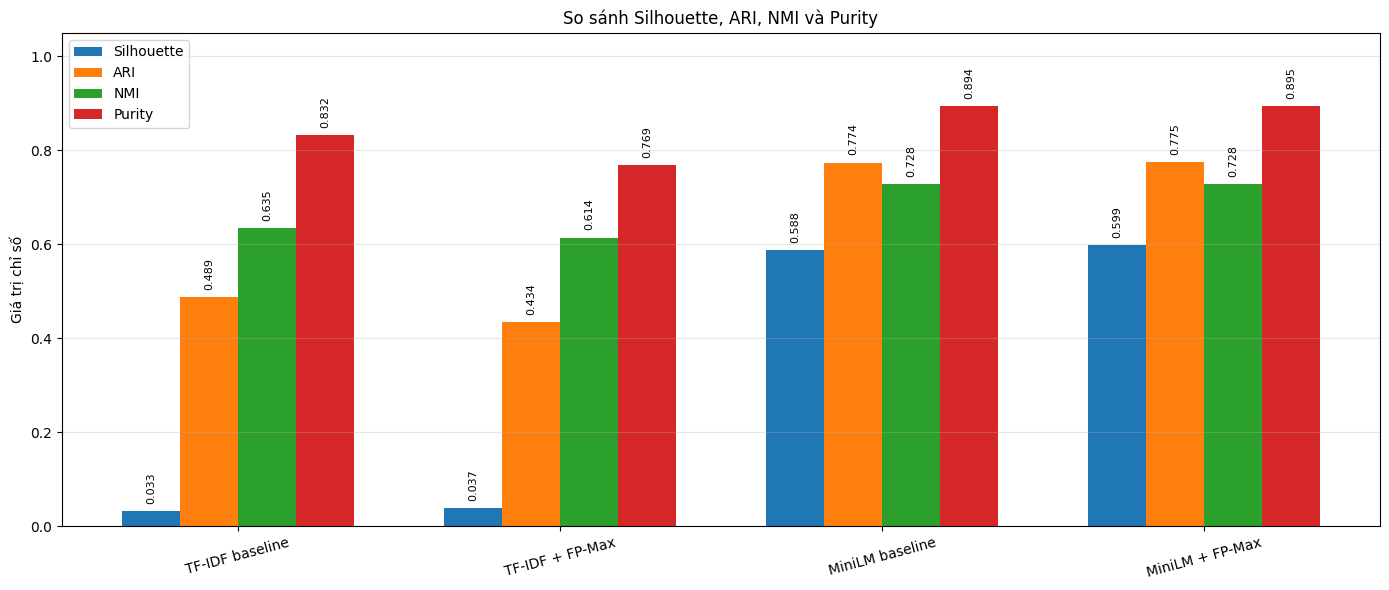

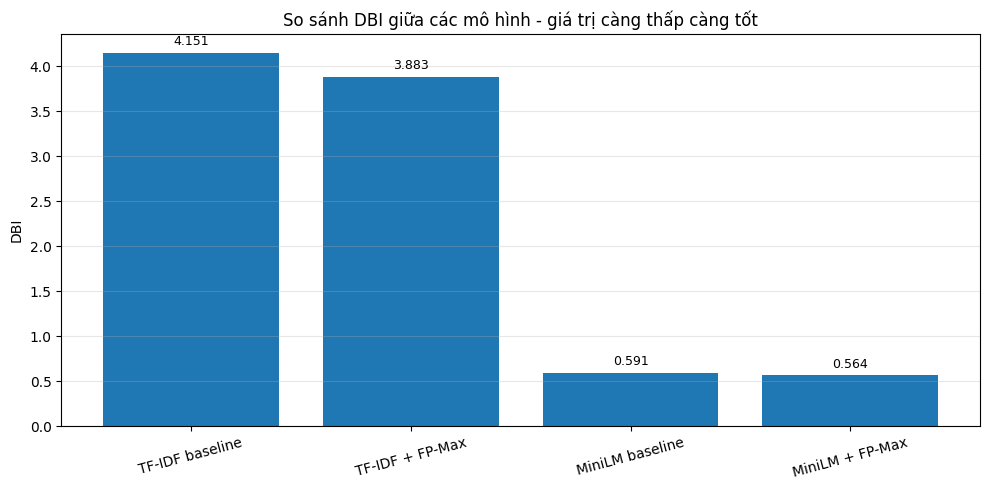

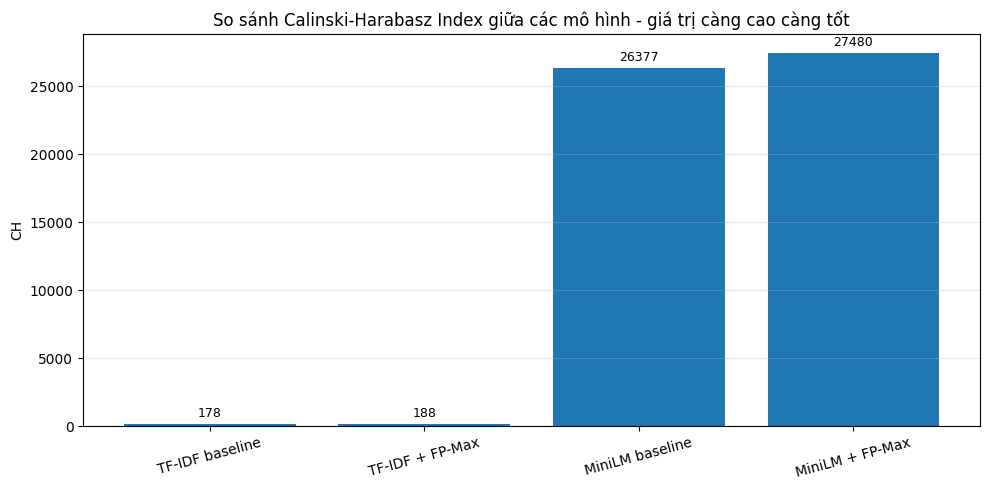

In [15]:
# Cell 5:So sánh tổng quát 4 mô hình chính

plot_df = final_results_df.copy()

# Hình 1A: Các chỉ số càng cao càng tốt, cùng thang 0-1
metrics_high_better = ["silhouette", "ari", "nmi", "purity"]
metric_labels_high = ["Silhouette", "ARI", "NMI", "Purity"]

x = np.arange(len(plot_df))
width = 0.18

plt.figure(figsize=(14, 6))

for i, metric in enumerate(metrics_high_better):
    values = plot_df[metric].astype(float).values

    bars = plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=metric_labels_high[i]
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

plt.xticks(x, plot_df["model_name"].astype(str), rotation=15)
plt.ylabel("Giá trị chỉ số")
plt.title("So sánh Silhouette, ARI, NMI và Purity")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Hình 1B: DBI riêng, càng thấp càng tốt
plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["model_name"].astype(str),
    plot_df["dbi"].astype(float).values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=15)
plt.ylabel("DBI")
plt.title("So sánh DBI giữa các mô hình - giá trị càng thấp càng tốt")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Hình 1C: CH riêng, càng cao càng tốt
plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["model_name"].astype(str),
    plot_df["ch"].astype(float).values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(plot_df["ch"]) * 0.01,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=15)
plt.ylabel("CH")
plt.title("So sánh Calinski-Harabasz Index giữa các mô hình - giá trị càng cao càng tốt")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét kết quả so sánh final

Bảng kết quả final và các biểu đồ cho thấy nhóm mô hình semantic sử dụng MiniLM vượt trội rõ rệt so với nhóm lexical baseline dựa trên TF-IDF. MiniLM baseline đạt Silhouette, ARI, NMI và Purity cao hơn nhiều, đồng thời có DBI thấp hơn đáng kể so với TF-IDF baseline.

Ở nhánh lexical, việc bổ sung FP-Max giúp Silhouette tăng nhẹ và DBI giảm, cho thấy cấu trúc cụm có cải thiện theo chỉ số nội tại. Tuy nhiên, ARI, NMI và Purity lại giảm, nên không thể kết luận rằng FP-Max cải thiện toàn diện cho TF-IDF baseline.

Ở nhánh semantic, mô hình `MiniLM + FP-Max` cải thiện nhẹ so với MiniLM baseline. Silhouette tăng, DBI giảm và CH tăng, cho thấy cấu trúc cụm của mô hình hybrid tách rõ hơn một chút. Các chỉ số hậu nghiệm như ARI, NMI và Purity cũng tăng nhẹ.

Nhìn chung, MiniLM là biểu diễn hiệu quả hơn cho bài toán gom cụm văn bản báo chí tiếng Việt. FP-Max không thay thế MiniLM, nhưng có thể đóng vai trò tín hiệu lexical bổ sung có kiểm soát và hỗ trợ khả năng diễn giải cụm.

In [17]:
# Cell 6: Phân tích mức cải thiện giữa các mô hình
# Cell này tính mức thay đổi chỉ số giữa các cặp mô hình quan trọng.

def get_model_row(df, model_name):
    """
    Lấy một dòng kết quả theo tên mô hình.
    """
    return df[df["model_name"].astype(str) == model_name].iloc[0]


def compare_two_models(df, base_model, compare_model, comparison_name):
    """
    So sánh mô hình compare_model với base_model.
    Với DBI, giá trị giảm là tốt hơn nên tạo thêm cột dbi_improvement.
    """
    base_row = get_model_row(df, base_model)
    compare_row = get_model_row(df, compare_model)

    metrics = ["silhouette", "dbi", "ch", "ari", "nmi", "purity"]

    result = {
        "comparison": comparison_name,
        "base_model": base_model,
        "compare_model": compare_model
    }

    for metric in metrics:
        base_value = float(base_row[metric])
        compare_value = float(compare_row[metric])

        result[f"{metric}_base"] = base_value
        result[f"{metric}_compare"] = compare_value
        result[f"delta_{metric}"] = compare_value - base_value

        # Tính % thay đổi nếu mẫu số khác 0
        if base_value != 0:
            result[f"relative_{metric}_percent"] = ((compare_value - base_value) / abs(base_value)) * 100
        else:
            result[f"relative_{metric}_percent"] = np.nan

    # Với DBI, giảm là tốt hơn
    result["dbi_improvement"] = float(base_row["dbi"]) - float(compare_row["dbi"])

    return result


improvement_rows = []

# 1. FP-Max trên nhánh lexical
improvement_rows.append(
    compare_two_models(
        final_results_df,
        base_model="TF-IDF baseline",
        compare_model="TF-IDF + FP-Max",
        comparison_name="TF-IDF + FP-Max vs TF-IDF"
    )
)

# 2. MiniLM semantic so với lexical baseline
improvement_rows.append(
    compare_two_models(
        final_results_df,
        base_model="TF-IDF baseline",
        compare_model="MiniLM baseline",
        comparison_name="MiniLM vs TF-IDF"
    )
)

# 3. Hybrid so với MiniLM baseline
improvement_rows.append(
    compare_two_models(
        final_results_df,
        base_model="MiniLM baseline",
        compare_model="MiniLM + FP-Max",
        comparison_name="MiniLM + FP-Max vs MiniLM"
    )
)

improvement_df = pd.DataFrame(improvement_rows)

# Chỉ hiển thị các cột quan trọng để bảng gọn hơn
display_columns = [
    "comparison",
    "delta_silhouette",
    "dbi_improvement",
    "delta_ch",
    "delta_ari",
    "delta_nmi",
    "delta_purity",
    "relative_silhouette_percent",
    "relative_ari_percent",
    "relative_nmi_percent",
    "relative_purity_percent"
]

print("Bảng phân tích mức cải thiện giữa các mô hình:")
display(improvement_df[display_columns])

Bảng phân tích mức cải thiện giữa các mô hình:


,comparison,delta_silhouette,dbi_improvement,delta_ch,delta_ari,delta_nmi,delta_purity,relative_silhouette_percent,relative_ari_percent,relative_nmi_percent,relative_purity_percent
0,TF-IDF + FP-Max vs TF-IDF,0.004417,0.268212,9.708670,-0.054205,-0.020453,-0.062564,13.366637,-11.094854,-3.222216,-7.519625
1,MiniLM vs TF-IDF,0.554659,3.560542,26199.202515,0.285355,0.093111,0.061533,1678.497755,58.407235,14.668895,7.395676
2,MiniLM + FP-Max vs MiniLM,0.011194,0.026530,1102.931641,0.000662,0.000395,0.001375,1.904637,0.085541,0.054328,0.153886


### Nhận xét mức cải thiện giữa các mô hình

Bảng phân tích mức cải thiện cho thấy FP-Max có tác động khác nhau tùy theo không gian biểu diễn.

Ở nhánh lexical, TF-IDF + FP-Max cải thiện nhẹ các chỉ số nội tại so với TF-IDF baseline. Cụ thể, Silhouette tăng khoảng `13.37%` và DBI giảm `0.2682`. Tuy nhiên, các chỉ số hậu nghiệm như ARI, NMI và Purity lại giảm. Do đó, FP-Max không cải thiện toàn diện chất lượng gom cụm của TF-IDF, mà chủ yếu làm thay đổi cấu trúc cụm theo hướng tốt hơn ở một số chỉ số nội tại.

Khi so sánh MiniLM với TF-IDF baseline, MiniLM cải thiện rất rõ ở hầu hết các chỉ số. Điều này cho thấy biểu diễn ngữ nghĩa từ MiniLM phù hợp hơn với bài toán gom cụm văn bản báo chí tiếng Việt so với biểu diễn lexical truyền thống.

Với mô hình hybrid, MiniLM + FP-Max cải thiện nhẹ so với MiniLM baseline. Silhouette tăng khoảng `1.90%`, DBI giảm `0.0265`, trong khi ARI, NMI và Purity cũng tăng nhẹ. Mức cải thiện không lớn, nhưng phù hợp với vai trò của FP-Max trong nghiên cứu này: một tín hiệu lexical bổ sung có kiểm soát, không thay thế biểu diễn ngữ nghĩa của MiniLM.

In [19]:
# Cell 7: Kiểm định Wilcoxon cho mô hình mạnh nhất
# So sánh MiniLM baseline và MiniLM + FP-Max với alpha = 0.05 trên nhiều random seed.

from scipy.stats import wilcoxon
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scipy.sparse as sp
import umap

# ------------------------------
# Hàm tính Purity
# ------------------------------
def purity_score(y_true, y_pred):
    """
    Tính Purity cho kết quả gom cụm.
    Với mỗi cụm, lấy nhãn thật xuất hiện nhiều nhất rồi cộng lại.
    """
    contingency_matrix = pd.crosstab(y_true, y_pred)
    return np.sum(np.max(contingency_matrix.values, axis=0)) / np.sum(contingency_matrix.values)


# ------------------------------
# Load lại đặc trưng cần thiết
# ------------------------------
X_minilm = np.load(FEATURES_DIR / "minilm_embeddings.npy")
X_fpmax = sp.load_npz(FEATURES_DIR / "fpmax_binary_features.npz")

y_true = df["category_clean"].values

# Chuẩn hóa giống đúng tinh thần Notebook 5
X_minilm_norm = normalize(X_minilm, norm="l2")
X_fpmax_norm = normalize(X_fpmax, norm="l2")

# ------------------------------
# Cấu hình kiểm định
# ------------------------------
seeds = [0, 1, 7, 21, 42, 123, 256, 512, 1024, 2024]
best_alpha = 0.05
n_clusters = 6
n_components = 100

test_rows = []

print("Bắt đầu chạy kiểm định Wilcoxon cho MiniLM baseline và MiniLM + FP-Max...")

for seed in seeds:
    print(f"\nSeed = {seed}")

    # ==============================
    # MiniLM baseline
    # ==============================
    reducer_base = umap.UMAP(
        n_components=n_components,
        random_state=seed
    )

    X_minilm_umap = reducer_base.fit_transform(X_minilm_norm)

    kmeans_base = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=10
    )

    labels_base = kmeans_base.fit_predict(X_minilm_umap)

    base_purity = purity_score(y_true, labels_base)
    base_ari = adjusted_rand_score(y_true, labels_base)
    base_nmi = normalized_mutual_info_score(y_true, labels_base)

    print(f"MiniLM baseline - Purity: {base_purity:.4f}, ARI: {base_ari:.4f}, NMI: {base_nmi:.4f}")

    # ==============================
    # MiniLM + FP-Max alpha = 0.05
    # ==============================
    X_hybrid = sp.hstack(
        [
            sp.csr_matrix(X_minilm_norm),
            best_alpha * X_fpmax_norm
        ],
        format="csr"
    )

    reducer_hybrid = umap.UMAP(
        n_components=n_components,
        random_state=seed
    )

    X_hybrid_umap = reducer_hybrid.fit_transform(X_hybrid)

    kmeans_hybrid = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=10
    )

    labels_hybrid = kmeans_hybrid.fit_predict(X_hybrid_umap)

    hybrid_purity = purity_score(y_true, labels_hybrid)
    hybrid_ari = adjusted_rand_score(y_true, labels_hybrid)
    hybrid_nmi = normalized_mutual_info_score(y_true, labels_hybrid)

    print(f"MiniLM + FP-Max - Purity: {hybrid_purity:.4f}, ARI: {hybrid_ari:.4f}, NMI: {hybrid_nmi:.4f}")

    test_rows.append({
        "seed": seed,
        "minilm_purity": base_purity,
        "hybrid_purity": hybrid_purity,
        "delta_purity": hybrid_purity - base_purity,
        "minilm_ari": base_ari,
        "hybrid_ari": hybrid_ari,
        "delta_ari": hybrid_ari - base_ari,
        "minilm_nmi": base_nmi,
        "hybrid_nmi": hybrid_nmi,
        "delta_nmi": hybrid_nmi - base_nmi
    })


wilcoxon_df = pd.DataFrame(test_rows)

print("\nKết quả 10 seeds:")
display(wilcoxon_df)


# ------------------------------
# Wilcoxon test
# ------------------------------
metrics_for_test = [
    ("purity", "minilm_purity", "hybrid_purity"),
    ("ari", "minilm_ari", "hybrid_ari"),
    ("nmi", "minilm_nmi", "hybrid_nmi")
]

wilcoxon_rows = []

for metric_name, base_col, hybrid_col in metrics_for_test:
    stat, p_value = wilcoxon(
        wilcoxon_df[base_col],
        wilcoxon_df[hybrid_col],
        alternative="less"
    )

    wilcoxon_rows.append({
        "metric": metric_name,
        "minilm_mean": wilcoxon_df[base_col].mean(),
        "hybrid_mean": wilcoxon_df[hybrid_col].mean(),
        "mean_delta": wilcoxon_df[hybrid_col].mean() - wilcoxon_df[base_col].mean(),
        "wilcoxon_statistic": stat,
        "p_value": p_value,
        "significant_0.05": p_value < 0.05
    })

wilcoxon_results_df = pd.DataFrame(wilcoxon_rows)

print("\nKết quả kiểm định Wilcoxon:")
display(wilcoxon_results_df)

Bắt đầu chạy kiểm định Wilcoxon cho MiniLM baseline và MiniLM + FP-Max...

Seed = 0


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MiniLM baseline - Purity: 0.8797, ARI: 0.7575, NMI: 0.7212


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MiniLM + FP-Max - Purity: 0.8822, ARI: 0.7622, NMI: 0.7245

Seed = 1


...

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MiniLM + FP-Max - Purity: 0.8748, ARI: 0.7471, NMI: 0.7128

Kết quả 10 seeds:


,seed,minilm_purity,hybrid_purity,delta_purity,minilm_ari,hybrid_ari,delta_ari,minilm_nmi,hybrid_nmi,delta_nmi
0,0,0.879684,0.882205,0.002521,0.757534,0.762239,0.004705,0.721181,0.724511,0.003330
1,1,0.878423,0.880486,0.002063,0.754227,0.759512,0.005285,0.716847,0.723162,0.006316
2,7,0.876934,0.878996,0.002063,0.751624,0.756188,0.004564,0.714566,0.720492,0.005926
3,21,0.876361,0.899736,0.023376,0.750867,0.787540,0.036672,0.713881,0.740510,0.026629
4,42,0.876361,0.880715,0.004354,0.750989,0.759212,0.008223,0.713117,0.723309,0.010191
5,123,0.880257,0.898934,0.018678,0.760206,0.786622,0.026416,0.723156,0.738431,0.015275
6,256,0.877507,0.875559,-0.001948,0.752742,0.749483,-0.003259,0.715845,0.716123,0.000278
7,512,0.873611,0.877392,0.003781,0.748053,0.752998,0.004946,0.713944,0.716464,0.002520
8,1024,0.878652,0.876819,-0.001833,0.755391,0.751290,-0.004101,0.719370,0.713489,-0.005882
9,2024,0.880486,0.874757,-0.005729,0.759834,0.747077,-0.012757,0.722731,0.712758,-0.009972



Kết quả kiểm định Wilcoxon:


,metric,minilm_mean,hybrid_mean,mean_delta,wilcoxon_statistic,p_value,significant_0.05
0,purity,0.877827,0.882560,0.004732,11.0,0.048828,True
1,ari,0.754147,0.761216,0.007069,11.0,0.052734,False
2,nmi,0.717464,0.722925,0.005461,11.0,0.052734,False


### Nhận xét kiểm định Wilcoxon giữa MiniLM baseline và MiniLM + FP-Max

Kiểm định Wilcoxon signed-rank test được thực hiện cho cặp mô hình `MiniLM baseline` và `MiniLM + FP-Max` trên 10 random seed. Đây là cặp so sánh trực tiếp để đánh giá liệu FP-Max có giúp cải thiện mô hình MiniLM hay không.

Kết quả cho thấy `MiniLM + FP-Max` có giá trị trung bình cao hơn `MiniLM baseline` ở cả ba chỉ số Purity, ARI và NMI. Cụ thể, Purity tăng trung bình khoảng `0.0047`, ARI tăng khoảng `0.0071` và NMI tăng khoảng `0.0055`.

Với kiểm định Wilcoxon, chỉ số Purity có `p-value = 0.0488 < 0.05`, cho thấy cải thiện về Purity của mô hình hybrid có ý nghĩa thống kê ở mức ý nghĩa 5%. Trong khi đó, ARI và NMI có `p-value = 0.0527`, tiệm cận ngưỡng 0.05 nhưng chưa đủ điều kiện để kết luận có ý nghĩa thống kê.

Như vậy, FP-Max khi ghép có kiểm soát với MiniLM giúp cải thiện nhẹ chất lượng gom cụm, đặc biệt thể hiện rõ ở Purity. Tuy nhiên, mức cải thiện không quá lớn, nên FP-Max nên được xem là tín hiệu lexical bổ sung và hỗ trợ diễn giải cụm, thay vì thay thế vai trò biểu diễn ngữ nghĩa của MiniLM.

In [23]:
# Cell 8: Tổng hợp khả năng diễn giải cụm bằng FP-Max pattern
# Cell này tập trung vào khả năng diễn giải cụm, không đánh giá theo hướng phân loại.
# FP-Max được dùng để mô tả các cụm bằng các mẫu từ vựng đồng xuất hiện đặc trưng.

interpretability_summary_df = pattern_interpretation_df.copy()

print("Các cột hiện có trong bảng diễn giải cụm:")
print(interpretability_summary_df.columns.tolist())

print("\nBảng tổng hợp diễn giải cụm bằng FP-Max pattern:")
display(interpretability_summary_df)

Các cột hiện có trong bảng diễn giải cụm:
['cluster_hybrid', 'dominant_category', 'cluster_size', 'cluster_purity', 'top_fpmax_patterns']

Bảng tổng hợp diễn giải cụm bằng FP-Max pattern:


,cluster_hybrid,dominant_category,cluster_size,cluster_purity,top_fpmax_patterns
0,0,the_thao,1449,0.924086,"ba, thứ; quốc_gia, thứ; trẻ, tuổi; quốc_gia, t..."
1,1,giao_duc,1882,0.904357,"giáo_dục, học, đào_tạo; giáo_dục, học_sinh, tr..."
2,2,xe,587,0.741056,"hệ_thống, một_số; hệ_thống, khả_năng; công_ngh..."
3,3,suc_khoe,2007,0.897359,"bệnh_nhân, bệnh_viện; bệnh, điều_trị; bệnh_việ..."
4,4,du_lich,1876,0.931770,"du_khách, du_lịch, khách; du_lịch, văn_hóa; du..."
5,5,cong_nghe,926,0.847732,"công_nghệ, khả_năng; công_nghệ, ứng_dụng; công..."


### Nhận xét khả năng diễn giải cụm bằng FP-Max pattern

Bảng diễn giải cụm cho thấy FP-Max giúp mô tả nội dung của từng cụm thông qua các mẫu từ vựng đồng xuất hiện đặc trưng. Phần này không nhằm đánh giá mô hình theo hướng phân loại, mà tập trung vào việc giải thích ý nghĩa của các cụm sau khi mô hình đã gom nhóm văn bản.

Các cụm có pattern khá phù hợp với nội dung nổi bật của từng nhóm. Ví dụ, cụm `suc_khoe` có các pattern liên quan đến `bệnh_nhân`, `bệnh_viện`, `bệnh`, `điều_trị`; cụm `du_lich` có các pattern như `du_khách`, `du_lịch`, `khách`, `văn_hóa`; cụm `cong_nghe` có các pattern liên quan đến `công_nghệ`, `khả_năng`, `ứng_dụng`.

Một số cụm vẫn có pattern còn mang tính chung hoặc bị nhiễu, chẳng hạn cụm `xe` xuất hiện các pattern như `hệ_thống`, `khả_năng`, `công_nghệ`. Điều này cho thấy FP-Max phản ánh đồng xuất hiện từ vựng trong dữ liệu, nên có thể xuất hiện các mẫu chung giữa những chủ đề có nội dung giao thoa như xe và công nghệ.

Nhìn chung, FP-Max không thay thế biểu diễn ngữ nghĩa MiniLM, nhưng có vai trò bổ sung tín hiệu lexical và giúp tăng khả năng diễn giải kết quả gom cụm. Đây là giá trị quan trọng của FP-Max trong nghiên cứu, đặc biệt khi mô hình hybrid chỉ cải thiện metric ở mức nhẹ.

### Nhận xét khả năng diễn giải cụm bằng FP-Max

Bảng tổng hợp cho thấy FP-Max có vai trò hỗ trợ diễn giải các cụm được tạo ra từ mô hình hybrid. Trong khi MiniLM biểu diễn văn bản bằng embedding ngữ nghĩa nên khó quan sát trực tiếp đặc trưng của từng cụm, FP-Max bổ sung các mẫu từ vựng đồng xuất hiện để giúp mô tả nội dung nổi bật của cụm.

Ở các cụm có độ tinh khiết cao như cụm `du_lich` (`cluster_purity = 0.9318`) và cụm `suc_khoe` (`cluster_purity = 0.8974`), các pattern được trích xuất khá phù hợp với chủ đề chính. Ví dụ, cụm `du_lich` xuất hiện các mẫu liên quan đến `du_khách`, `du_lịch`, `khách`, `văn_hóa`, trong khi cụm `suc_khoe` có các mẫu như `bệnh_nhân`, `bệnh_viện`, `bệnh`, `điều_trị`. Điều này cho thấy FP-Max có thể hỗ trợ định danh và mô tả nội dung của cụm một cách dễ hiểu hơn.

Đáng chú ý, cụm `xe` có `cluster_purity = 0.7411`, thấp hơn các cụm còn lại. Tuy nhiên, các pattern phổ biến của cụm này lại chứa những từ như `hệ_thống`, `khả_năng`, `công_nghệ`. Điều này gợi ý rằng sự pha trộn không nhất thiết đến từ lỗi gom cụm nghiêm trọng, mà có thể phản ánh sự giao thoa ngữ nghĩa trong dữ liệu báo chí. Các bài viết về xe hiện đại, xe điện, công nghệ hỗ trợ lái hoặc hệ thống vận hành thường chia sẻ nhiều từ vựng với chủ đề công nghệ.

Như vậy, FP-Max không thay thế biểu diễn ngữ nghĩa MiniLM, nhưng giúp bổ sung cơ sở từ vựng minh bạch để giải thích nội dung cụm và hiện tượng giao thoa chủ đề. Đây là giá trị quan trọng của FP-Max trong nghiên cứu, đặc biệt khi mô hình hybrid chỉ cải thiện chỉ số đánh giá ở mức nhẹ.

# Trả lời các câu hỏi nghiên cứu

### RQ1: MiniLM có cải thiện chất lượng gom cụm văn bản báo chí tiếng Việt so với TF-IDF/BM25 không?

Kết quả thực nghiệm cho thấy MiniLM cải thiện rõ rệt chất lượng gom cụm so với các baseline lexical như TF-IDF và BM25. Trong bảng so sánh final, MiniLM baseline đạt Silhouette cao hơn, DBI thấp hơn và CH cao hơn nhiều so với TF-IDF baseline. Điều này cho thấy không gian biểu diễn ngữ nghĩa của MiniLM giúp các văn bản cùng chủ đề được gom gần nhau hơn và các cụm tách biệt rõ hơn.

Tuy nhiên, các chỉ số hậu nghiệm như ARI, NMI và Purity chỉ được dùng để tham khảo mức độ tương ứng với chuyên mục gốc, không biến bài toán thành phân loại. Nhìn chung, MiniLM là biểu diễn phù hợp hơn cho bài toán gom cụm văn bản báo chí tiếng Việt so với biểu diễn lexical truyền thống.

### RQ2: FP-Max enrichment có cải thiện hoặc thay đổi chất lượng gom cụm của TF-IDF baseline không?

Kết quả cho thấy việc bổ sung FP-Max vào TF-IDF làm thay đổi chất lượng gom cụm theo hướng không hoàn toàn đồng nhất. TF-IDF + FP-Max có Silhouette tăng nhẹ và DBI giảm so với TF-IDF baseline, cho thấy cấu trúc cụm được cải thiện ở một số chỉ số nội tại. Tuy nhiên, ARI, NMI và Purity lại giảm.

Vì vậy, không thể kết luận rằng FP-Max cải thiện toàn diện TF-IDF baseline. Vai trò của FP-Max trong nhánh lexical phù hợp hơn với việc bổ sung tín hiệu đồng xuất hiện từ vựng và hỗ trợ diễn giải, thay vì đảm bảo luôn làm tăng mọi chỉ số đánh giá.

### RQ3: FP-Max pattern features có thể bổ sung khả năng diễn giải và/hoặc cải thiện chất lượng gom cụm khi ghép có kiểm soát với MiniLM không?

Kết quả cho thấy MiniLM + FP-Max đạt kết quả tốt hơn nhẹ so với MiniLM baseline. Trong bảng final, mô hình hybrid có Silhouette cao hơn, DBI thấp hơn và CH cao hơn MiniLM baseline. Khi kiểm định Wilcoxon trên 10 random seed, mô hình hybrid có giá trị trung bình cao hơn MiniLM baseline ở Purity, ARI và NMI. Trong đó, cải thiện về Purity đạt ý nghĩa thống kê ở mức 5%, còn ARI và NMI tiệm cận ngưỡng ý nghĩa thống kê.

Bên cạnh cải thiện về chỉ số, FP-Max còn đóng vai trò quan trọng trong khả năng diễn giải cụm. Các pattern đồng xuất hiện giúp mô tả nội dung nổi bật của từng cụm và giải thích hiện tượng giao thoa ngữ nghĩa giữa một số chủ đề, chẳng hạn cụm `xe` có liên hệ từ vựng với `công_nghệ`, `hệ_thống` và `khả_năng`.

Như vậy, FP-Max không thay thế MiniLM, nhưng có thể bổ sung tín hiệu lexical có kiểm soát và giúp tăng khả năng giải thích kết quả gom cụm.